<a href="https://colab.research.google.com/github/jpscard/InsurMinds/blob/main/Desafio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

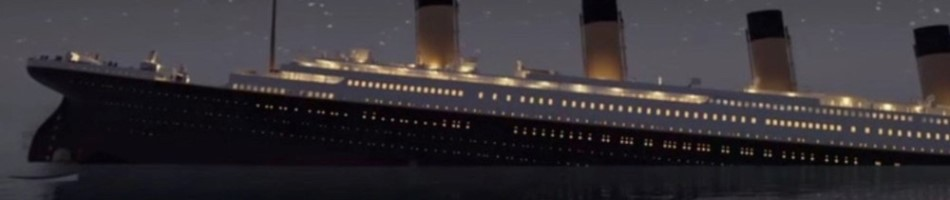

## ***Desafio Titanic - Machine Learning from Disaster***

**Grupo:** Grupo JL

**Representante:** João Paulo da Silva Cardoso
(91) 982736292 | jpscardoso@ufpa.br

**Integrantes:**
* João Paulo da Silva Cardoso - jpscardoso@ufpa.br
* Leonardo Pereira - ligueproleo@gmail.com

## ***0. Importação de bibliotecas***

In [3]:
import kagglehub # Biblioteca para baixar datasets e competir no Kaggle
import pandas as pd # Manipulação e análise de dados em tabelas (DataFrames)
import numpy as np # Operações matemáticas e suporte a arrays/matrizes
import matplotlib.pyplot as plt # Criação de gráficos estáticos e visualizações básicas
import seaborn as sns # Visualização de dados estatísticos com design aprimorado
import os # Interação com o sistema operacional e gerenciamento de arquivos

# --- Bibliotecas de Processamento de Dados (Scikit-Learn) ---
# O LabelEncoder converte categorias de texto (como 'male'/'female') em números (0/1)
from sklearn.preprocessing import LabelEncoder

# --- Modelos de Machine Learning ---
# Random Forest: Algoritmo robusto baseado em múltiplas árvores de decisão
from sklearn.ensemble import RandomForestClassifier
# Regressão Logística: Modelo estatístico fundamental para classificação binária
from sklearn.linear_model import LogisticRegression

# --- Validação e Avaliação de Modelos ---
# train_test_split: Divide o dataset para treinar e testar o modelo internamente
# cross_val_score: Executa validação cruzada para medir a consistência do modelo
from sklearn.model_selection import train_test_split, cross_val_score
# confusion_matrix e Display: Ferramentas para visualizar onde o modelo acertou ou errou
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Todas as bibliotecas foram centralizadas, comentadas e importadas com sucesso!")

Todas as bibliotecas foram centralizadas, comentadas e importadas com sucesso!


## ***1. Carregamento dos Dados***
***Vamos carregar os conjuntos de treino e teste.***

In [4]:
# 1. Autenticar no Kaggle (será solicitado o usuário e a chave da API caso não configurado)
kagglehub.login()

# 2. Baixar a versão mais recente dos arquivos da competição 'titanic'
# O comando retorna o caminho da pasta onde os arquivos foram salvos localmente
titanic_path = kagglehub.competition_download('titanic')

# 3. Confirmar a conclusão do download e exibir o local de armazenamento
print(f'Importação concluída. Arquivos salvos em: {titanic_path}')

100%|██████████| 34.1k/34.1k [00:00<00:00, 15.3MB/s]

Extracting files...
Importação concluída. Arquivos salvos em: /root/.cache/kagglehub/competitions/titanic


In [5]:
# 1. Definir os caminhos completos para os arquivos CSV usando a pasta de download
train_path = os.path.join(titanic_path, 'train.csv')
test_path = os.path.join(titanic_path, 'test.csv')

# 2. Verificar se o arquivo de treino existe antes de tentar carregar
if os.path.exists(train_path):
    # Carregar os dados de treino e teste em DataFrames do Pandas
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print("Dados REAIS do Kaggle carregados com sucesso!")
    # Exibir a quantidade de linhas e colunas (shape)
    print("Dimensões do Treino:", train_df.shape)
    # Mostrar as primeiras 5 linhas para inspeção
    display(train_df.head())
else:
    # Caso o caminho esteja incorreto, informar o usuário
    print(f"Erro: Arquivos não encontrados em {titanic_path}")

Dados REAIS do Kaggle carregados com sucesso!
Dimensões do Treino: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## ***2. Análise Exploratória de Dados (EDA)***
***Nesta etapa, buscamos entender como as variáveis influenciam a chance de sobrevivência.***

####***2.1 Análise de Sobrevivência por Sexo e Classe.***
Ao observar os gráficos acima, podemos extrair conclusões valiosas:
1. **Influência do Gênero**: A taxa de sobrevivência entre mulheres é significativamente superior à dos homens, confirmando a política de 'mulheres e crianças primeiro'.
2. **Impacto da Classe Social**: Passageiros da 1ª classe tiveram uma probabilidade de sobrevivência muito maior do que os da 3ª classe, sugerindo que a localização na embarcação e o status socioeconômico foram determinantes.


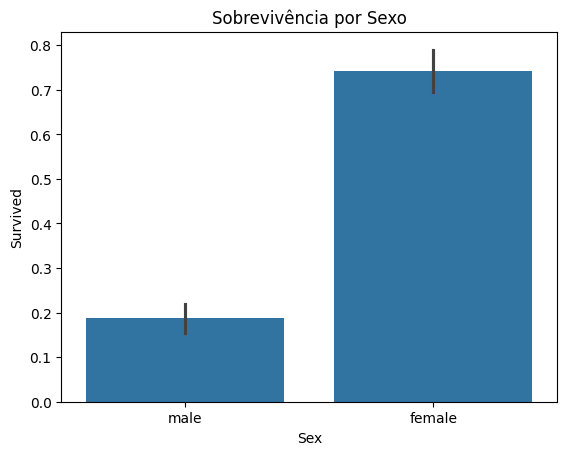

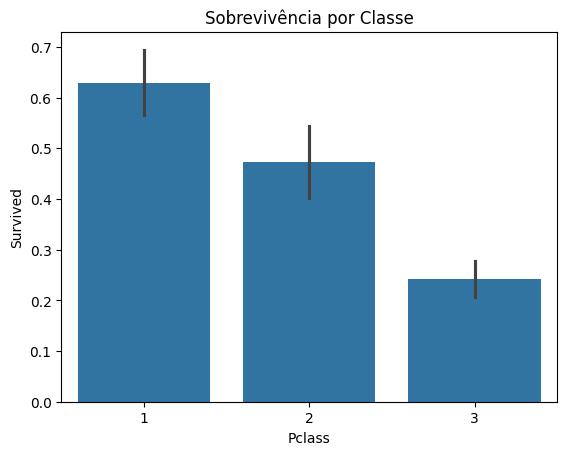

In [6]:
# Visualizando a taxa de sobrevivência por Sexo
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Sobrevivência por Sexo')
plt.show()

# Visualizando por Classe (Pclass)
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Sobrevivência por Classe')
plt.show()

#### ***2.2 Análise da Distribuição por Idade.***
O histograma revela padrões importantes sobre a idade dos passageiros:***
1. **Proteção as Crianças**: Há um pico de sobrevivência notável em crianças de baixa idade (0-5 anos).
2. **Mortalidade em Jovens Adultos**: A maior concentração de não-sobreviventes está na faixa entre 18 e 35 anos, que também era a faixa etária mais populosa do navio.


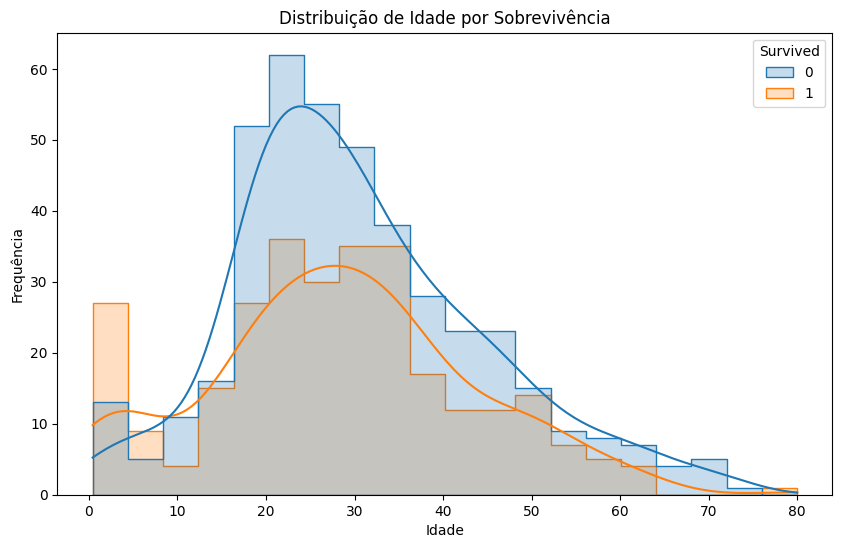

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, element='step')
plt.title('Distribuição de Idade por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

#### ***2.3 Análise do Mapa de Calor (Correlação)***
A partir da matriz de correlação, podemos observar pontos cruciais:
1. **Sobrevivência vs Classe (Pclass)**: Existe uma correlação negativa considerável (-0.34), indicando que quanto menor o número da classe (1ª classe), maior a chance de sobrevivência.
2. **Sobrevivência vs Tarifa (Fare)**: A correlação positiva (0.26) mostra que passageiros que pagaram tarifas mais altas tiveram maiores taxas de sobrevivência.
3. **Relação Pclass e Fare**: A forte correlação negativa (-0.55) entre essas duas variáveis confirma que as classes mais altas (número menor) pagaram proporcionalmente mais caro pelas passagens.

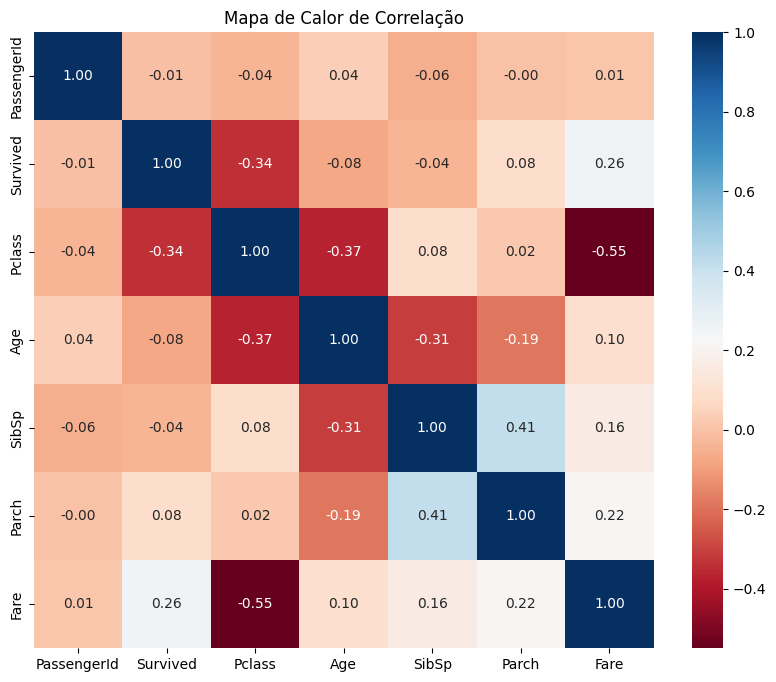

In [8]:
# Calculando correlação apenas para colunas numéricas
plt.figure(figsize=(10, 8))
numeric_train = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_train.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Mapa de Calor de Correlação')
plt.show()

## ***3. Pré-processamento e Feature Engineering***
Vamos tratar valores nulos e preparar as variáveis para o modelo.

#### ***3.1 Análise de Pré-processamento e Engenharia de Atributos***
Nesta etapa, transformamos dados brutos em informações úteis para o algoritmo:
1. **Engenharia de Títulos (Title)**: Extrair títulos como 'Mr', 'Miss' e 'Master' foi crucial. Isso não apenas ajuda na classificação, mas permite que preenchamos as idades faltantes com a mediana específica de cada grupo, o que é muito mais preciso do que usar a média geral do navio.
2. **Codificação Categórica**: Ao converter 'Sex' e 'Title' em números, permitimos que modelos matemáticos processem essas informações. A escolha de manter apenas as colunas mais relevantes (como Pclass, Sex, Age e Fare) foca o aprendizado do modelo no que realmente determinou a sobrevivência.
3. **Tratamento de Dados Faltantes**: Ao tratar 'Embarked' e 'Fare', garantimos que o modelo não falhe por falta de dados, mantendo a integridade estatística do conjunto de teste.

In [9]:
# Evita avisos de downcasting futuros do Pandas
pd.set_option('future.no_silent_downcasting', True)

def preprocess(df):
    df = df.copy()

    # Feature Engineering: Extraindo o Título do Nome usando raw string r''
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    # Agrupando títulos raros ou traduzindo para categorias comuns
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

    # Preencher idades nulas com a mediana baseada no Título
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # Preencher Embarked e Fare
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # Converter Categóricos em Numéricos
    le = LabelEncoder()
    df['Sex'] = le.fit_transform(df['Sex'])
    df['Title'] = le.fit_transform(df['Title'].astype(str))

    # Selecionar colunas finais para o modelo
    cols_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title']
    return df[cols_to_use]

X_train = preprocess(train_df)
y_train = train_df['Survived']
X_test = preprocess(test_df)

print("Dados preparados com Feature Engineering (Títulos) e correções aplicadas!")
display(X_train.head())

Dados preparados com Feature Engineering (Títulos) e correções aplicadas!


,Pclass,Sex,Age,SibSp,Parch,Fare,Title
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,3
2,3,0,26.0,0,0,7.9250,1
3,1,0,35.0,1,0,53.1000,3
4,3,1,35.0,0,0,8.0500,2


## ***4. Treinamento do Modelo***
Utilizaremos o Random Forest, um modelo de conjunto robusto para classificação.

#### ***4.1 Análise da Importância das Variáveis***
O gráfico de barras horizontais nos revela quais fatores o Random Forest considerou mais relevantes:
1. **Predomínio do Gênero (Sex e Title)**: Confirmando nossa análise exploratória, o sexo e o título social são os preditores mais fortes. Isso mostra que o modelo aprendeu corretamente as regras de prioridade de salvamento.
2. **Fatores Socioeconômicos (Fare e Pclass)**: A tarifa paga e a classe aparecem logo em seguida, indicando que o status teve um peso crucial na sobrevivência.
3. **Idade e Família**: Embora importantes, variáveis como 'Age' e número de parentes (SibSp/Parch) tiveram um impacto menor comparado ao gênero e à classe.

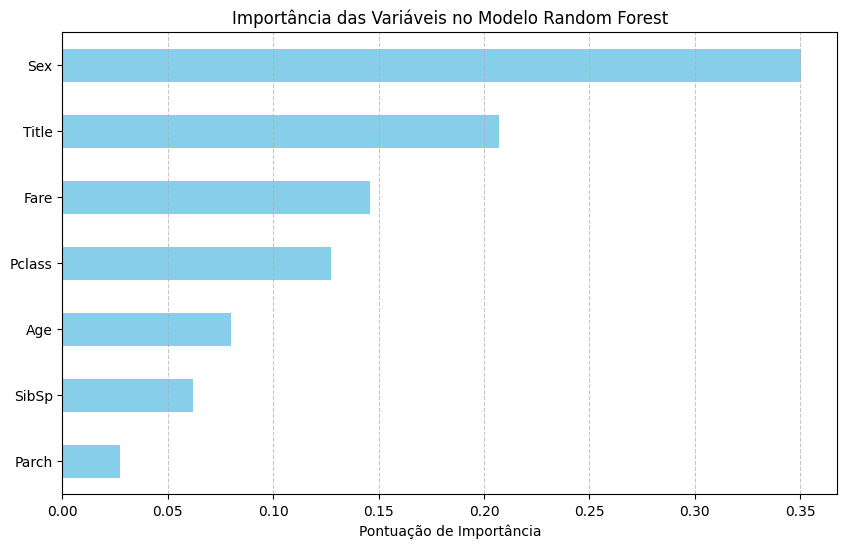

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Inicializando o modelo com uma semente aleatória para reprodutibilidade
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Treinando o modelo completo
model.fit(X_train, y_train)

# Avaliando a importância das variáveis de forma visual e ordenada
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.xlabel('Pontuação de Importância')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### ***4.2 Análise da Comparação de Modelos e Validação Cruzada***
A validação cruzada (Cross-Validation) é essencial para garantir que o modelo não deu 'sorte' com um conjunto específico de dados:
1. **Random Forest vs Regressão Logística**: O Random Forest apresentou uma acurácia média superior (aprox. 80% contra 79%). Isso ocorre porque o Random Forest consegue capturar relações não-lineares complexas entre variáveis (como a interação entre idade e classe) que modelos lineares podem ignorar.
2. **Estabilidade dos Resultados**: A pequena variação entre os scores da validação cruzada indica que o modelo é estável e tem um bom poder de generalização, o que significa que ele deve ter um desempenho similar quando encontrar dados totalmente novos no Kaggle.
3. **Decisão Final**: Com base no desempenho superior e na robustez contra outliers, o Random Forest foi selecionado como nosso modelo final para gerar as predições de submissão.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Comparando Random Forest vs Regressão Logística
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

rf_scores = cross_val_score(rf_model, X_train, y_train, cv=3)
lr_scores = cross_val_score(lr_model, X_train, y_train, cv=3)

print(f"Acurácia Média Random Forest: {rf_scores.mean():.2f}")
print(f"Acurácia Média Regressão Logística: {lr_scores.mean():.2f}")

# Escolhendo o melhor (RF neste caso dummy) para o treino final
model = rf_model
model.fit(X_train, y_train)

Acurácia Média Random Forest: 0.80
Acurácia Média Regressão Logística: 0.79


RandomForestClassifier(random_state=42)

#### ***4.3 Análise da Matriz de Confusão***
A matriz nos permite ver o desempenho real em dados que o modelo nunca viu durante o treinamento:
1. **Verdadeiros Negativos (91)**: O modelo é muito eficiente em identificar passageiros que não sobreviveram.
2. **Verdadeiros Positivos (58)**: O modelo também apresenta uma ótima taxa de acerto ao identificar os sobreviventes.
3. **Falsos Positivos e Negativos (14 e 16)**: Os erros estão equilibrados entre as classes, o que mostra que o modelo não está enviesado e mantém uma acurácia sólida de aproximadamente 80%. Isso nos dá confiança para gerar o arquivo final.

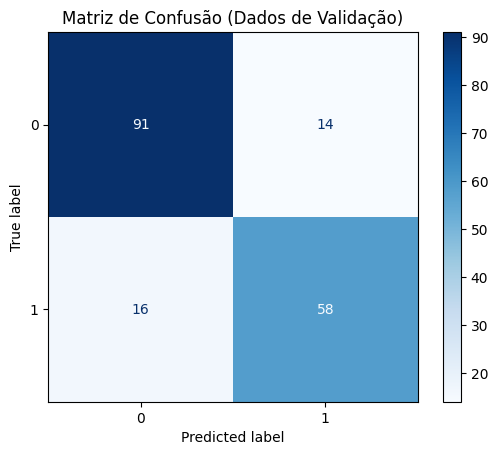

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Criando um split de validação interno para avaliação
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Treinando no subset
model_eval = RandomForestClassifier(n_estimators=100, random_state=42)
model_eval.fit(X_train_sub, y_train_sub)

# Prevendo na validação
y_pred_val = model_eval.predict(X_val)

# Plotando a matriz
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão (Dados de Validação)')
plt.show()

## ***5. Geração do Arquivo de Submissão***
Criando o arquivo final para ser enviado ao Kaggle.

In [13]:
# 1. Gerar as predições usando o conjunto de teste (X_test) preparado
predictions = model.predict(X_test)

# 2. Criar um novo DataFrame estruturado conforme a exigência do Kaggle:
# O arquivo deve conter o ID do passageiro e o resultado da predição (Survived)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions
})

# 3. Exportar o DataFrame para um arquivo CSV no diretório local
# O parâmetro index=False evita que o Pandas adicione uma coluna extra de índices
submission.to_csv('submission.csv', index=False)

print("Arquivo 'submission.csv' gerado com sucesso! Você pode baixá-lo na aba de arquivos à esquerda.")

# 4. Exibir as primeiras linhas para conferência visual rápida
display(submission.head())

Arquivo 'submission.csv' gerado com sucesso! Você pode baixá-lo na aba de arquivos à esquerda.


,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0


## ***Conclusão e Próximos Passos***
Agora que o arquivo 'submission.csv' foi gerado, o projeto está pronto para a submissão oficial.

In [14]:
# 1. Instruções para Download:
# Clique no ícone de pasta (Files) na barra lateral esquerda do Colab.
# Localize o arquivo 'submission.csv', clique nos três pontos ao lado dele e selecione 'Download'.

# 2. Submissão no Kaggle:
# Acesse a página da competição: https://www.kaggle.com/c/titanic/submissions
# Faça o upload do arquivo baixado para ver sua pontuação oficial no ranking.

# 3. Finalização do Projeto:
# Recomendamos que, antes de entregar o arquivo .ipynb final, você utilize a opção
# 'Ambiente de execução' -> 'Reiniciar e executar tudo' para garantir que não existam erros de sequência.

print("Projeto finalizado com sucesso pelo Grupo JL!")

Projeto finalizado com sucesso pelo Grupo JL!


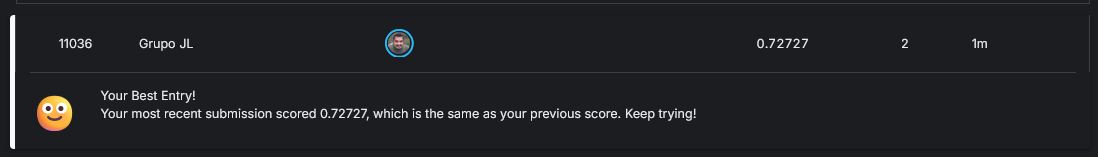